## CAPSTONE PROJEKTAS_Data Analytics_Python



## Pardavimų ir klientų elgsenos analizė 

 Duomenų supratimas ir paruošimas 

In [1]:
# Gera praktika analizę pradėti nuo reikalingų bibliotekų įkėlimo.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import scipy.stats as stats

In [2]:
# Įkeliami duomenys, su kuriais bus atliekama analizė.

df = pd.read_csv("C:/Users/erika/OneDrive/Desktop/Python/SuperMarket Analysis.csv")

# Peržiūrime pirmas kelias eilutes, kad susipažintume su duomenų struktūra.
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
print("Shape:", df.shape) # Patikriname, kiek duomenų rinkinyje yra eilučių ir stulpelių

Shape: (1000, 17)


In [4]:
df.nunique() #Patikriname, kiek turime unikalių reikšmių

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Sales                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

In [5]:
df.isna().sum()  # Patikriname, ar yra trūkstamų (null) reikšmių

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [6]:
df.info() # Peržiūrime duomenų tipus ir bendrą informaciją apie stulpelius

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
df.describe().T # Peržiūrime pagrindinius skaitinių kintamųjų rodiklius (count, mean, min, max, 25% , 50%, 75%, std.)

,count,mean,std,min,25%,50%,75%,max
Unit price,1000.0,55.672130,26.494628,10.080000,32.875000,55.230000,77.935000,99.960000
Quantity,1000.0,5.510000,2.923431,1.000000,3.000000,5.000000,8.000000,10.000000
Tax 5%,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Sales,1000.0,322.966749,245.885335,10.678500,124.422375,253.848000,471.350250,1042.650000
cogs,1000.0,307.587380,234.176510,10.170000,118.497500,241.760000,448.905000,993.000000
gross margin percentage,1000.0,4.761905,0.000000,4.761905,4.761905,4.761905,4.761905,4.761905
gross income,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Rating,1000.0,6.972700,1.718580,4.000000,5.500000,7.000000,8.500000,10.000000


In [8]:
df.columns # Peržiūrime visų stulpelių pavadinimus ir įvertiname, ar jie tvarkingi

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [9]:
df["Date"] = pd.to_datetime(df["Date"]) # Konvertuojame Date stulpelį į datetime formatą.


In [10]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour # Konvertuojame Time į datetime ir išskiriame valandą.

C:\Users\erika\AppData\Local\Temp\ipykernel_196\2126486714.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour # Konvertuojame Time į datetime ir išskiriame valandą.


Duomenų rinkinį sudaro 1000 eilučių ir 17 stulpeli('Invoice ID', 'Branch', 'City', 'Customer type', 'Gender','Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date','Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income','Rating').

Patikrinus duomenis matome, kad duomenų rinkinyje nėra trūkstamų (null) reikšmių, todėl papildomas duomenų valymas čia nėra reikalingas. Duomenų tipai yra tinkami tolimesnei analizei.

## Aprašomoji analizė (EDA) 

In [11]:
print(f"Pardavimų suma: {df['Sales'].sum()}")
print(f"Pardavimų vidurkis: {df['Sales'].mean()}")
print(f"Pardavimų mediana: {df['Sales'].median()}")
print(f"Pardavimų standartinis nuokrypis: {df['Sales'].std()}")
print(f"Mažiausia užsakymo suma: {df['Sales'].min()}")
print(f"Didžiausia užsakymo suma: {df['Sales'].max()}")

Pardavimų suma: 322966.749
Pardavimų vidurkis: 322.966749
Pardavimų mediana: 253.848
Pardavimų standartinis nuokrypis: 245.88533510097187
Mažiausia užsakymo suma: 10.6785
Didžiausia užsakymo suma: 1042.65


In [12]:
df.describe().T # Pamatome pagrindinius skaitinių kintamųjų rodiklius (count, mean, min, max, 25% , 50%, 75%, std.)


,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
Date,1000,2019-02-14 00:05:45.600000,2019-01-01 00:00:00,2019-01-24 00:00:00,2019-02-13 00:00:00,2019-03-08 00:00:00,2019-03-30 00:00:00,NaN
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858
Hour,1000.0,14.91,10.0,12.0,15.0,18.0,20.0,3.186857


In [13]:
pivot_table = df.pivot_table(values="Sales", index="Branch", columns="Date", aggfunc="sum") # Peržiūrime, kokie buvo pardavimai kiekviename filiale pagal datą.
pivot_table

Date,2019-01-01,2019-01-02,2019-01-03,2019-01-04,2019-01-05,2019-01-06,2019-01-07,2019-01-08,2019-01-09,2019-01-10,...,2019-03-21,2019-03-22,2019-03-23,2019-03-24,2019-03-25,2019-03-26,2019-03-27,2019-03-28,2019-03-29,2019-03-30
Branch,,,,,,,,,,,,,,,,,,,,,
Alex,2371.320,307.0515,937.4085,483.2625,2024.5050,1309.9695,1105.9545,683.4555,202.3350,731.493,...,1308.7305,2128.056,1748.376,424.6200,577.1220,1187.340,1060.6260,1652.9310,977.613,1320.6165
Cairo,1536.696,1162.8015,1016.6940,510.5835,486.7590,1021.6395,1341.9105,2208.9480,168.5250,1348.599,...,207.8580,1051.092,384.468,1564.7835,418.0890,301.203,898.8945,95.6655,2059.932,1724.4570
Giza,837.165,475.6500,124.0260,629.8425,1025.4195,1282.5960,386.3790,2401.3290,2650.4835,1480.857,...,360.9270,NaN,1962.198,1488.0600,1277.7555,473.970,943.2990,480.8055,985.698,1441.9860


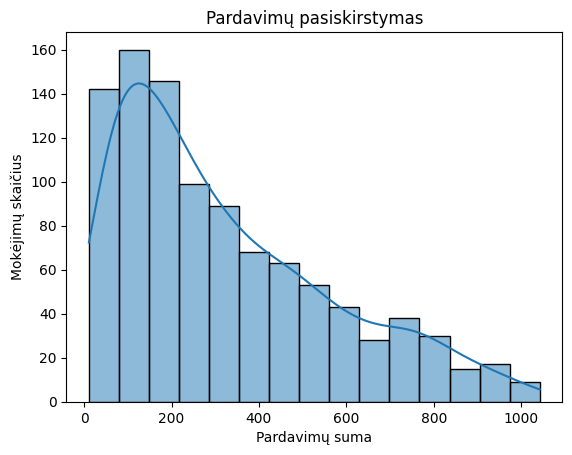

In [14]:
# Lentelė Nr.1
# Vaizduojame pardavimų pasiskirstymą pagal mokėjimų skaičių
sns.histplot(df["Sales"], kde=True)
plt.title("Pardavimų pasiskirstymas")
plt.xlabel("Pardavimų suma")
plt.ylabel("Mokėjimų skaičius")
plt.show()

Išanalizavus lentelę galime pastebėti, kad pardavimų pasiskirstymas nėra simetriškas – dauguma mokėjimų koncentruojasi mažesnių sumų intervale, tačiau pasitaiko ir keli didesni pardavimai.

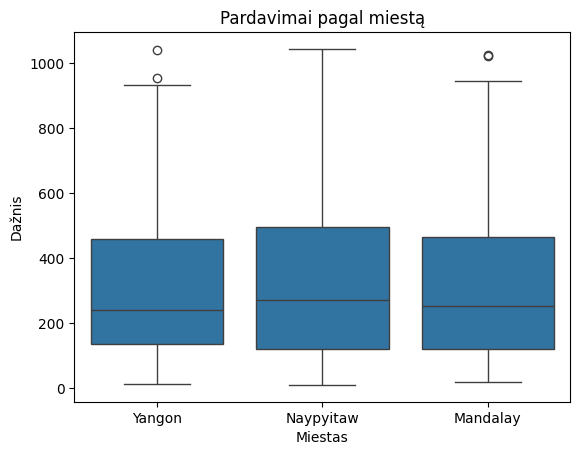

In [15]:
# Lentelė Nr.2
# Lyginame pardavimų sumų pasiskirstymą tarp skirtingų miestų

sns.boxplot(data=df, x="City", y="Sales")
plt.title("Pardavimai pagal miestą")
plt.xlabel("Miestas")
plt.ylabel("Dažnis")
plt.show()

In [16]:
df["City"].value_counts()

City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

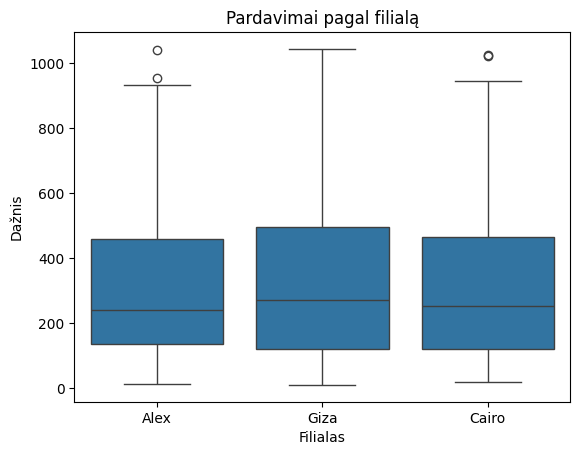

In [17]:
# Lentelė Nr.3
# Lyginame pardavimų sumų pasiskirstymą tarp skirtingų filialų
sns.boxplot(data=df, x="Branch", y="Sales")
plt.title("Pardavimai pagal filialą")
plt.xlabel("Filialas")
plt.ylabel("Dažnis")
plt.show()

In [18]:
df["Branch"].value_counts()

Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

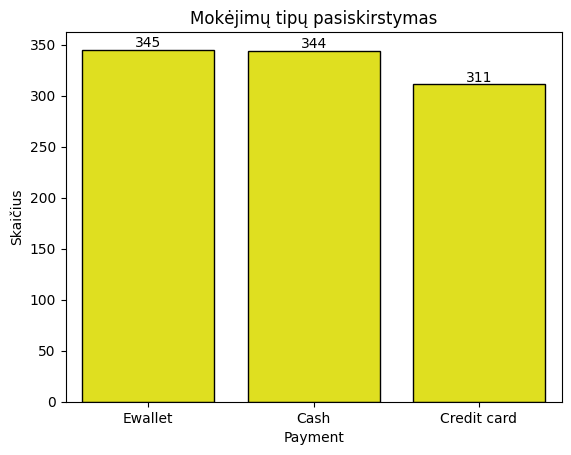

In [19]:
# Lentelė Nr.4
# Parodome, kiek kartų buvo pasirinktas kiekvienas mokėjimo būdas
# Įvertiname, kuris mokėjimo tipas yra populiariausias pagal mokėjimų skaičių
ax = sns.countplot(data=df, x="Payment",color="yellow", edgecolor="black")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Mokėjimų tipų pasiskirstymas")
plt.xlabel("Payment")
plt.ylabel("Skaičius")
plt.show()

Išanalizavus lentelę matome, kad duomenyse yra trys mokėjimo tipai. Populiariausias mokėjimo būdas buvo Ewallet (elektroniniai piniginė) – šiuo būdu atlikti 345 mokėjimai. Labai nedaug atsiliko mokėjimai grynaisiais (Cash) – 344 mokėjimai. Kreditine kortele (Credit card) buvo atlikta 311 mokėjimų. Tai rodo, kad klientai panašiai dažnai renkasi skirtingus mokėjimo būdus, tačiau šiek tiek dažniau naudojasi elektroninėmis atsiskaitymo priemonėmis.

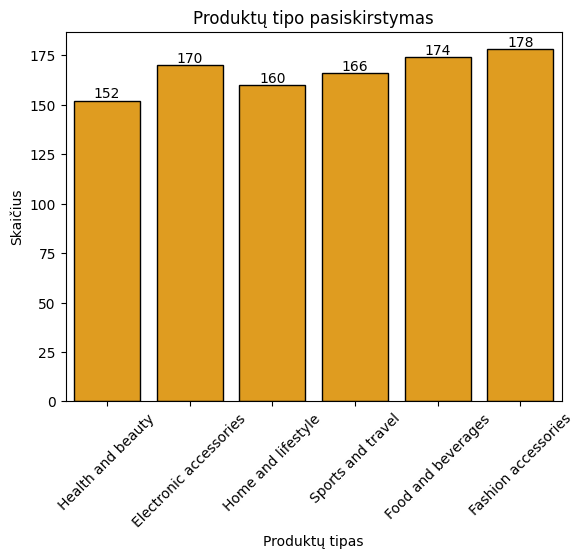

In [20]:
# Lentelė Nr.5
# Parodome, kiek kartų buvo pasirinkta kiekviena produktų linija.
# Įvertiname, kuri produktų linija yra populiariausia pagal mokėjimų skaičių.
ax = sns.countplot(data=df, x="Product line",color="orange", edgecolor="black")

for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)
plt.title("Produktų tipo pasiskirstymas")
plt.xlabel("Produktų tipas")
plt.ylabel("Skaičius")
plt.show()

Analizuojant Product line (produktų linijas) matyti, kad daugiausia pirkimų atlikta kategorijoje Fashion accessories (mados aksesuarai) – 178. Šiek tiek mažiau – Food and beverages (maistas ir gėrimai) – 174 bei Electronic accessories (elektroniniai aksesuarai) – 170. Skirtumai tarp šių kategorijų nėra dideli, todėl galima teigti, kad paklausa tarp pagrindinių produktų grupių yra gana tolygiai pasiskirsčiusi.

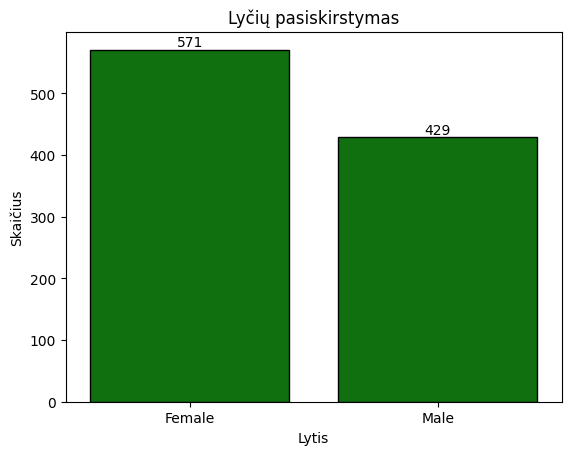

In [21]:
# Lentelė Nr.6
# Įvertiname, kuri lytis buvo aktyvesnė pagal atliktų mokėjimų skaičių
ax = sns.countplot(data=df, x="Gender",color="green", edgecolor="black")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Lyčių pasiskirstymas")
plt.xlabel("Lytis")
plt.ylabel("Skaičius")
plt.show()

Matome, kad didesnę dalį pirkimų atliko Female (moterys) – 571 mokėjimas, tuo tarpu Male (vyrai) – 492 mokėjimus. Tai rodo, kad moterys buvo šiek tiek aktyvesnės pirkėjos.


In [22]:
# Apskaičiuojame dienos pardavimų sumą
pardavimų_data = df.groupby("Date")["Sales"].sum()

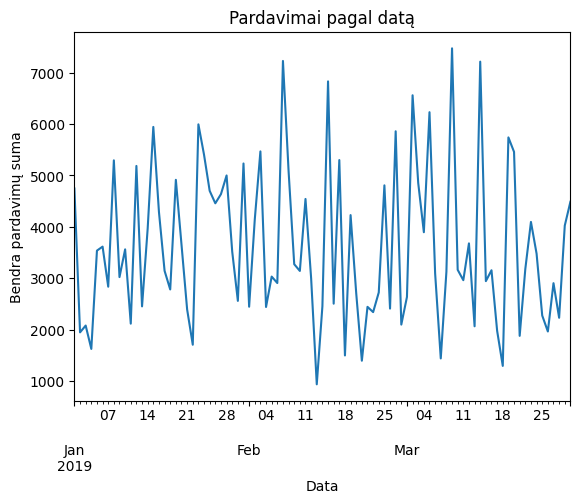

In [23]:
# Lentelė Nr.7
# Analizuojame, kaip keičiasi bendri pardavimai skirtingomis dienomis
pardavimų_data.plot(kind="line")
plt.title("Pardavimai pagal datą")
plt.xlabel("Data")
plt.ylabel("Bendra pardavimų suma")
plt.show()

Pardavimų grafikas pagal datą rodo, kad pardavimų suma skirtingomis dienomis svyruoja. Nėra aiškios nuoseklios augimo ar mažėjimo tendencijos, todėl galima teigti, kad pardavimai per nagrinėjamą laikotarpį nebuvo stabiliai didėjantys ar mažėjantys. Matomi atskiri pardavimų pikai ir kritimai, kurie gali būti susiję su skirtingu klientų aktyvumu tam tikromis dienomis.

Pardavimų svyravimai gali būti susiję su įvairiais veiksniais, tokiais kaip savaitės diena, valstybinės ar asmeninės šventės, taip pat galimos akcijos ar specialūs pasiūlymai.

In [24]:
# Pasitikrinam ar lentele parode gerus duomenis apie pardavimus pagal datą.
total_sales_by_date = df.groupby("Date")["Sales"].sum().sort_index()
total_sales_by_date

Date
2019-01-01    4745.1810
2019-01-02    1945.5030
2019-01-03    2078.1285
2019-01-04    1623.6885
2019-01-05    3536.6835
                ...    
2019-03-26    1962.5130
2019-03-27    2902.8195
2019-03-28    2229.4020
2019-03-29    4023.2430
2019-03-30    4487.0595
Name: Sales, Length: 89, dtype: float64

In [25]:
# Suruopuojame pardavimus pagal valandas.
pardavimų_valanda= df.groupby("Hour")["Sales"].sum()

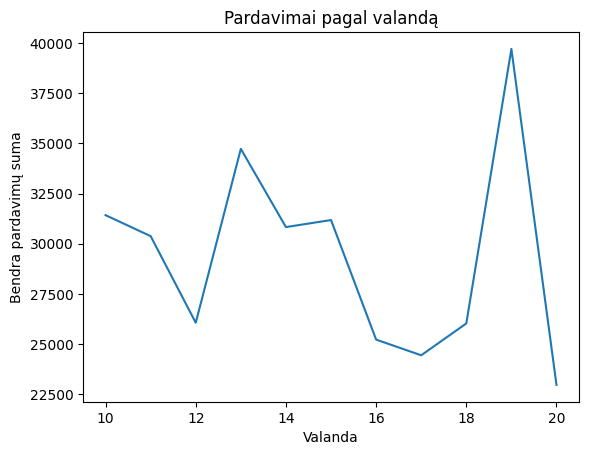

In [26]:
# Lentelė Nr.8
# Analizuojame, kaip keičiasi bendri pardavimai skirtingomis valandomis
pardavimų_valanda.plot(kind="line")
plt.title("Pardavimai pagal valandą")
plt.xlabel("Valanda")
plt.ylabel("Bendra pardavimų suma")
plt.show()

Pardavimų analizė pagal valandą rodo, kad didžiausias pardavimų pikas fiksuojamas apie 19:00 val. Tai leidžia manyti, kad klientai dažniausiai apsiperka vakare, tikėtina – po darbo valandų. Tai gali būti susiję su didesniu klientų aktyvumu laisvu laiku.

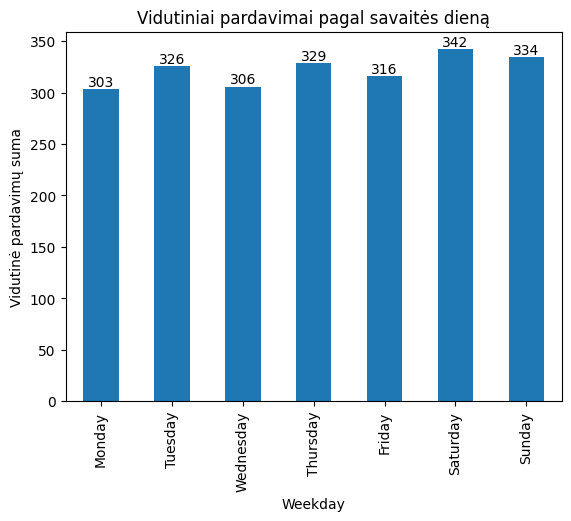

In [27]:
# Lentelė Nr.9
# Pasižiūrim ar yra savaitės sezoniškumas.
df["Weekday"] = df["Date"].dt.day_name()

weekday_sales = df.groupby("Weekday")["Sales"].mean()

weekday_sales = weekday_sales.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

ax = weekday_sales.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f") 
    
plt.title("Vidutiniai pardavimai pagal savaitės dieną")
plt.ylabel("Vidutinė pardavimų suma")
plt.show()

Lentelės analizė rodo, kad ryškaus savaitės sezoniškumo nepastebėta. Tačiau matyti, kad šiek tiek didesnis klientų aktyvumas fiksuojamas šeštadieniais (Saturday). Pardavimų suma šią dieną siekia 342. Vis dėlto skirtumas nėra didelis, todėl galima teigti, kad pardavimai per savaitę pasiskirstę gana tolygiai.

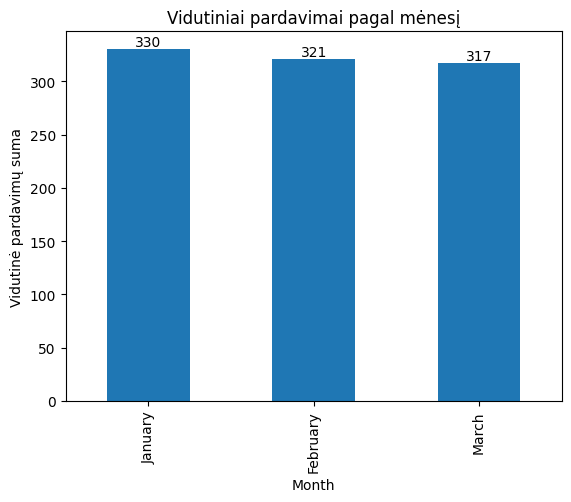

In [28]:
# Lentelė Nr.10
# Pasižiūrim ar yra mėnesio sezoniškumas.
df["Month"] = df["Date"].dt.month_name()

month_sales = df.groupby("Month")["Sales"].mean()

# Kad mėnesiai būtų teisinga tvarka
month_sales = month_sales.reindex(["January", "February", "March"])

ax = month_sales.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Vidutiniai pardavimai pagal mėnesį")
plt.ylabel("Vidutinė pardavimų suma")
plt.show()

Lentelės analizė rodo, kad ryškaus mėnesinio sezoniškumo nepastebėta. Tačiau matyti, kad šiek tiek didesnis klientų aktyvumas fiksuojamas January (sau). Pardavimų suma šią dieną siekia 342. Vis dėlto skirtumas nėra didelis, todėl galima teigti, kad pardavimai per mėnesį pasiskirstę gana tolygiai.

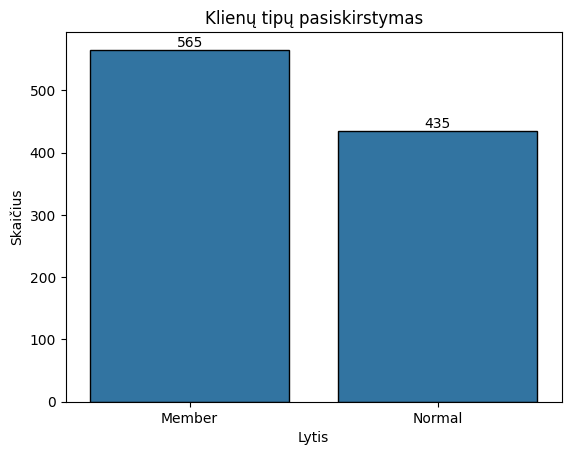

In [29]:
# Lentelė Nr.11
# Įvertiname, kuris klientų tipas buvo aktyvesnis pagal atliktų pirkimų skaičių
ax = sns.countplot(data=df, x="Customer type", edgecolor="black")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Klienų tipų pasiskirstymas")
plt.xlabel("Lytis")
plt.ylabel("Skaičius")
plt.show()

Grafikas rodo, kad Member tipo klientų yra daugiau (565) nei Normal klientų (435). Tai leidžia teigti, kad lojalumo programos dalyviai sudaro didesnę klientų dalį.

##  Pasikliautiniai intervalai 


In [35]:
# Apskaičiuojame 95 % pasikliautinį intervalą gross income vidurkiui
col = "gross income"
x = df[col].dropna().astype(float).values 
n = len(x)
mean = x.mean()
std = x.std(ddof=1)

alpha = 0.05 
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
se = std / np.sqrt(n)

ci_low = mean - t_crit * se
ci_high = mean + t_crit * se

mean, (ci_low, ci_high), n

(np.float64(15.379368999999999),
 (np.float64(14.652781515543746), np.float64(16.10595648445625)),
 1000)

Remiantis 1000 mokėjimų imtimi, apskaičiuotas 95 % pasikliautinis intervalas rodo, kad tikrasis vidutinis gross income populiacijoje tikėtina yra tarp 14.65 ir 15.38. Kadangi intervalas yra gana siauras, galima teigti, jog vidurkio įvertinimas yra pakankamai tikslus ir stabilus.

Intervalo siaurumas rodo, kad imtis yra pakankamai didelė, o duomenų variacija nėra labai didelė, todėl rezultatu galima pasitikėti.

## Hipotezių testavimas 

In [36]:
# Atliekame Welch t-test, kad patikrintume, ar skiriasi vidutinė pardavimo suma tarp skirtingų klientų tipų.
# t-test (Welch)
# H0: vidurkiai vienodi
# Ha: vidurkiai skiriasi

target = "Sales"
group = "Customer type"

g1 = df.loc[df[group] == "Member", target].dropna().astype(float)
g2 = df.loc[df[group] == "Normal", target].dropna().astype(float)

t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
diff_means = g1.mean() - g2.mean()
t_stat, p_val, diff_means

(np.float64(1.8862430247260686),
 np.float64(0.059565974044416076),
 np.float64(29.370565822398532))

Welch t-test parodė, kad statistiškai reikšmingo skirtumo tarp Member ir Normal klientų pardavimų nenustatyta (p > 0.05).

In [37]:
# Atliekame ANOVA analizę, kad patikrintume, ar skiriasi vidutiniai pardavimai tarp skirtingų filialų
# Test ANOVA
# H0: visų grupių vidurkiai vienodi
# Ha: bent vienos grupės vidurkis skiriasi

target = "Sales"
group = "Branch"

groups = [g.dropna().astype(float).values for _, g in df.groupby(group)[target]]
f_stat, p_val = stats.f_oneway(*groups)
f_stat, p_val

(np.float64(0.8845828327760511), np.float64(0.4132101743674147))

ANOVA testas neparodė reikšmingų skirtumų tarp filialų (p > 0.05).

In [38]:
# Atliekame Chi-kvadrato testą, kad patikrintume, ar yra ryšys tarp mokėjimo tipo ir lyties

# Test Chi-square
# H0: kintamieji nepriklausomi
# Ha: kintamieji priklausomi

cat1 = "Payment"
cat2 = "Gender"

ct = pd.crosstab(df[cat1], df[cat2])
chi2, p_val, dof, expected = stats.chi2_contingency(ct)
chi2, p_val, dof

(np.float64(3.5758429677349355), np.float64(0.16730755997629787), 2)

Chi-kvadrato testas parodė, kad ryšio tarp mokėjimo tipo ir lyties nenustatyta (p > 0.05).

Apibendrinant hipotezių testų rezultatus galima teigti, kad statistiškai reikšmingų skirtumų tarp klientų tipų, filialų bei mokėjimo pasirinkimų nenustatyta

## Analitinė dalis:

In [39]:
target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "City", "Customer type", "Gender", "Product line", "Payment"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

# Dummy + float (kritiška dėl ValueError)
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OLS
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     476.4
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:53:34   Log-Likelihood:                -4656.9
No. Observations:                 800   AIC:                             9342.
Df Residuals:                     786   BIC:                             9407.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             -232.6292      8.673    -26.821      0.000    -249.655    -215.603
Unit price                           5.8164      0.111     52.195      0.000       5.598       6.035
Quantity                            58.0899      0.997     58.246      0.000      56.132      60.048
Branch_Cairo                       -96.8009      5.173    -18.714      0.000    -106.955     -86.647
Branch_Giza                        -43.6224      2.933    -14.875      0.000     -49.379     -37.866
City_Naypyitaw                     -43.6224      2.933    -14.875      0.000     -49.379     -37.866
City_Yangon                        -92.2059      5.230    -17.629      0.000    -102.473     -81.939
Customer type_Normal                 6.3761      5.939      1.074      0.283      -5.281      18.033
Gender_Male                         -8.8453      6.015     -1.470      0.142     -20.654       2.963
Product line_Fashion accessories     1.0353     10.050      0.103      0.918     -18.693      20.764
Product line_Food and beverages      4.0893      9.901      0.413      0.680     -15.345      23.524
Product line_Health and beauty      -4.5996     10.486     -0.439      0.661     -25.184      15.985
Product line_Home and lifestyle      7.3666     10.295      0.716      0.474     -12.842      27.575
Product line_Sports and travel      -2.4939     10.103     -0.247      0.805     -22.326      17.338
Payment_Credit card                  9.7494      7.248      1.345      0.179      -4.479      23.977
Payment_Ewallet                     -1.9548      7.115     -0.275      0.784     -15.922      12.012
==============================================================================
Omnibus:                        0.161   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.923   Jarque-Bera (JB):                0.161
Skew:                          -0.034   Prob(JB):                        0.923
Kurtosis:                       2.987   Cond. No.                     2.44e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.07e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [40]:
# Prognozės ir metrikos ant test
pred_test = model.predict(sm.add_constant(X_test))

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

{"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}

{'R2_test': 0.9014751606096123,
 'MAE_test': 59.53709396800661,
 'RMSE_test': 80.06202689467587}

R2 parodo, kad modelis paaiškina 90% pardavimų svyravimų.

Mae parodo, kad vidutiniškai modelis suklysta apie 59 piniginius vienetus.

Rmse parodo, kad modelio vidutinė prognozės paklaida yra apie 80 piniginių vienetų.

In [41]:
ts = df.groupby("Date")["Sales"].sum().sort_index()
ts.head()

Date
2019-01-01    4745.1810
2019-01-02    1945.5030
2019-01-03    2078.1285
2019-01-04    1623.6885
2019-01-05    3536.6835
Name: Sales, dtype: float64

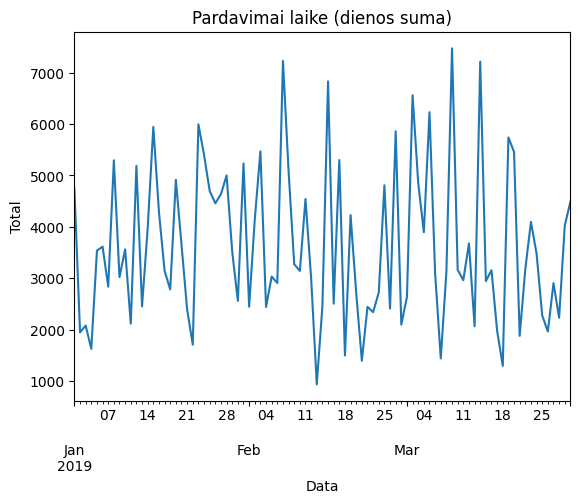

In [ ]:
# Lentelė Nr.12
ts.plot(title="Pardavimai laike (dienos suma)")
plt.xlabel("Data")
plt.ylabel("Total")
plt.show()

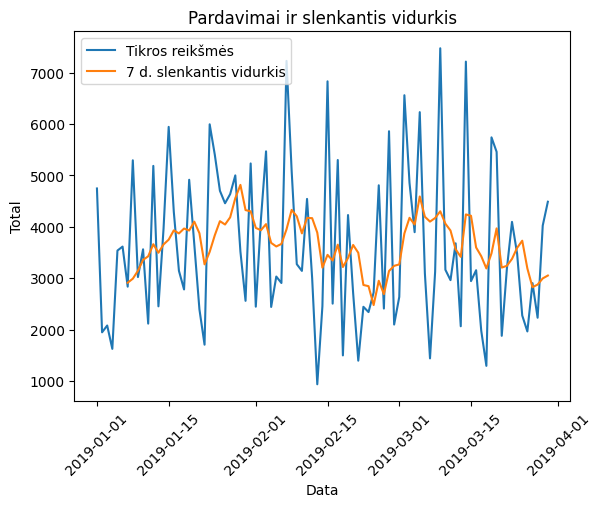

In [ ]:
# Lentelė Nr.13
# Paprasta prognozė su slenkančiu vidurkiu
window = 7
ts_ma = ts.rolling(window=window).mean()

plt.figure()
plt.plot(ts.index, ts.values, label="Tikros reikšmės")
plt.plot(ts_ma.index, ts_ma.values, label=f"{window} d. slenkantis vidurkis")
plt.title("Pardavimai ir slenkantis vidurkis")
plt.xlabel("Data")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.legend()
plt.show()


Lentelės analizė parodė, kad pardavimai pasižymi dideliais kasdieniais svyravimais. Tačiau 7 dienų slenkantis vidurkis rodo, kad aiškios ilgalaikės augimo ar mažėjimo tendencijos per analizuojamą laikotarpį nepastebėta. Pardavimai išlieka gana stabilūs su trumpalaikiais pakilimais ir kritimais.